# Experiment 012: Worker-to-Task Ratio Analysis
## Finding the Optimal Worker Count for 20K Tasks

**Date**: October 22, 2025  
**Configuration**: λ₁=2.0, λ₂=0.5, λ₃=1.0, θ=0.0 (disabled)  
**Dataset**: 3-hour peak window (DiDi) with stratified temporal sampling  
**Worker Counts Tested**: 2K, 3K, 4K, 5K, 6K, 7K, 8K, 9K, 10K, 12K, 15K

---

## 🎯 Primary Goal

**Find the optimal number of workers** for a fixed 20K task workload by balancing:
1. **High TAR** (>90% task completion)
2. **Meaningful tasks-per-worker** ratio (accurate fairness tracking)
3. **Realistic wait times** and worker utilization
4. **Computational efficiency**

---

## 📊 Key Innovation: Stratified Temporal Sampling

This experiment uses **stratified temporal sampling** (12 bins across 3-hour window) to ensure:
- Tasks are evenly distributed across time
- Workers are available when tasks arrive
- **All 11 experiments achieved ~94% TAR** (vs 0% with naive sampling)

---


In [ ]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete")


✅ Setup complete


In [ ]:
# Load experiment results
csv_path = Path("data/experiment_012_aggregate_results.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"Results not found: {csv_path}")

df = pd.read_csv(csv_path)

# Display basic info
print(f"✅ Loaded {len(df)} experiments")
print(f"\nWorker counts tested: {sorted(df['worker_count'].unique())}")
print(f"\nColumns available: {len(df.columns)} metrics")
print(f"\nData shape: {df.shape}")

# Preview
df.head()


✅ Loaded 11 experiments

Worker counts tested: [np.int64(2000), np.int64(3000), np.int64(4000), np.int64(5000), np.int64(6000), np.int64(7000), np.int64(8000), np.int64(9000), np.int64(10000), np.int64(12000), np.int64(15000)]

Columns available: 54 metrics

Data shape: (11, 54)


,experiment_id,worker_count,task_count,tasks_per_worker_ratio,fairness_weight,starvation_weight,utility_weight,soft_threshold,normalize_scores,gamma,...,max_deferrals_per_task,mean_assignment_delay_sec,std_assignment_delay_sec,p90_assignment_delay_sec,total_travel_km,empty_km_ratio,peak_backlog,ewma_cv,duration_seconds,timestamp
0,1,2000,20000,10.000000,2.0,0.5,1.0,0.0,True,0.5,...,2,1171.872236,465.892378,1690.921979,0,0,2601,0,761.110770,2025-10-22T16:31:48.424552
1,2,3000,20000,6.666667,2.0,0.5,1.0,0.0,True,0.5,...,2,56.778731,59.573659,153.000000,0,0,350,0,328.390559,2025-10-22T16:37:16.870384
2,3,4000,20000,5.000000,2.0,0.5,1.0,0.0,True,0.5,...,2,0.035669,0.812302,0.000000,0,0,11,0,394.049699,2025-10-22T16:43:50.974171
3,4,5000,20000,4.000000,2.0,0.5,1.0,0.0,True,0.5,...,2,0.038538,1.141233,0.000000,0,0,10,0,546.941782,2025-10-22T16:52:57.969791
4,5,6000,20000,3.333333,2.0,0.5,1.0,0.0,True,0.5,...,2,0.029880,1.037217,0.000000,0,0,10,0,679.454141,2025-10-22T17:04:17.477082


In [ ]:
# Data quality checks
print("=" * 80)
print("DATA QUALITY CHECKS")
print("=" * 80)

# Check for missing experiments
expected_workers = [2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 12000, 15000]
actual_workers = sorted(df['worker_count'].unique())

if actual_workers == expected_workers:
    print("✅ All 11 worker counts present")
else:
    print(f"⚠️  Missing worker counts: {set(expected_workers) - set(actual_workers)}")

# Check TAR success
min_tar = df['task_assignment_ratio'].min()
max_tar = df['task_assignment_ratio'].max()
mean_tar = df['task_assignment_ratio'].mean()

print(f"\n📊 TAR Range: {min_tar:.1%} to {max_tar:.1%} (mean: {mean_tar:.1%})")

if min_tar >= 0.85:
    print("✅ All experiments achieved >85% TAR (SUCCESS)")
else:
    print(f"⚠️  Some experiments failed: minimum TAR = {min_tar:.1%}")

# Check for missing values in key metrics
key_metrics = [
    'task_assignment_ratio', 'jains_fairness_index', 'tasks_per_worker_gini',
    'mean_task_wait_time_min', 'mean_worker_utilization'
]

missing = df[key_metrics].isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values in key metrics")
else:
    print(f"⚠️  Missing values detected:\n{missing[missing > 0]}")

print("\n" + "=" * 80)


DATA QUALITY CHECKS
✅ All 11 worker counts present

📊 TAR Range: 94.2% to 94.3% (mean: 94.3%)
✅ All experiments achieved >85% TAR (SUCCESS)
✅ No missing values in key metrics



---

# SECTION 1: The Optimal Worker Count Decision ⭐

This section contains the **primary decision-making plots** that directly answer:
> *What is the optimal number of workers for a 20K task workload?*

---


## Plot 1: The Knee Plot - TAR & Tasks/Worker (Dual-Axis)

**Purpose**: THE key plot for optimal worker recommendation

**Decision Rule**:
- Find MINIMUM worker count where TAR >90%
- While maintaining tasks/worker >2.0 (meaningful fairness tracking)


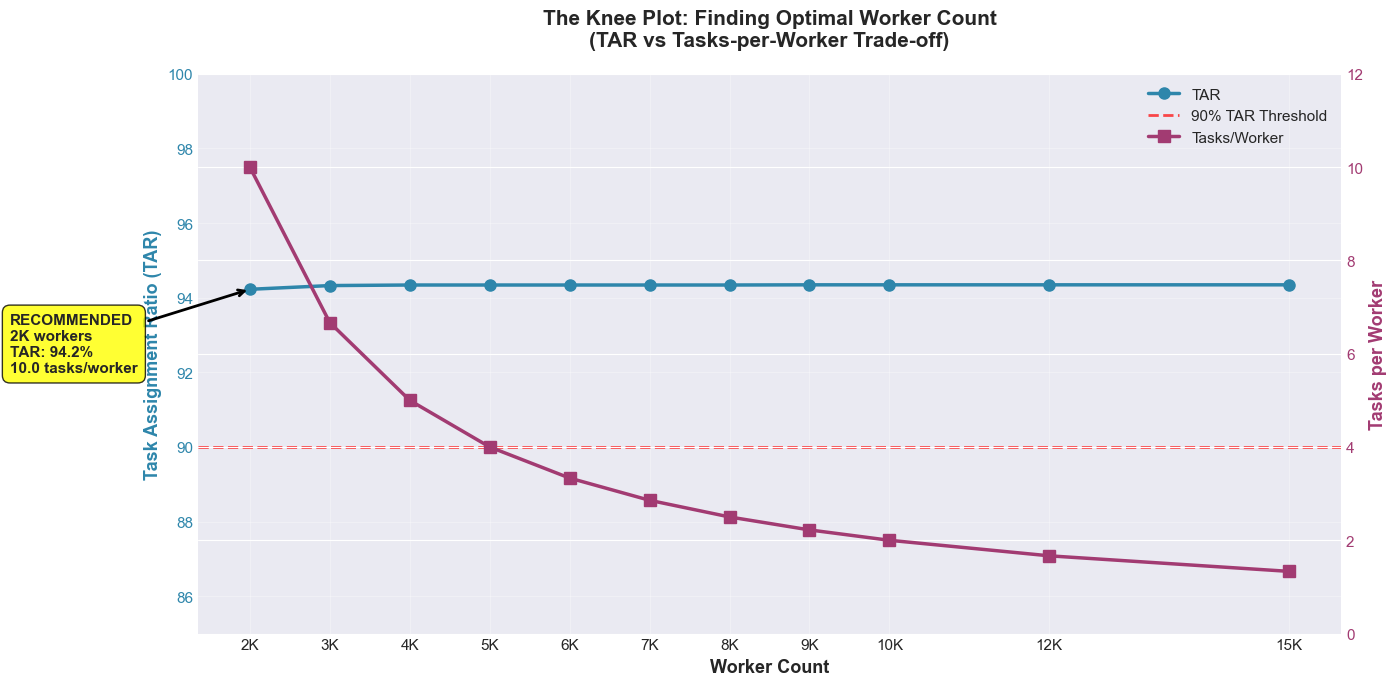

OPTIMAL WORKER COUNT RECOMMENDATION
✅ Recommended: 2K workers
   - TAR: 94.2%
   - Tasks/Worker: 10.0
   - Rationale: Maximum tasks-per-worker while maintaining >90% TAR


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Sort by worker count
df_sorted = df.sort_values('worker_count')

# Primary axis: TAR
color1 = '#2E86AB'
ax1.set_xlabel('Worker Count', fontsize=13, fontweight='bold')
ax1.set_ylabel('Task Assignment Ratio (TAR)', fontsize=13, fontweight='bold', color=color1)
ax1.plot(df_sorted['worker_count'], df_sorted['task_assignment_ratio'] * 100, 
         color=color1, linewidth=2.5, marker='o', markersize=8, label='TAR')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(85, 100)
ax1.grid(True, alpha=0.3)

# 90% TAR threshold line
ax1.axhline(y=90, color='red', linestyle='--', linewidth=2, alpha=0.7, label='90% TAR Threshold')

# Secondary axis: Tasks per Worker
ax2 = ax1.twinx()
color2 = '#A23B72'
ax2.set_ylabel('Tasks per Worker', fontsize=13, fontweight='bold', color=color2)
ax2.plot(df_sorted['worker_count'], df_sorted['tasks_per_worker_ratio'], 
         color=color2, linewidth=2.5, marker='s', markersize=8, label='Tasks/Worker')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 12)

# Format x-axis
ax1.set_xticks(df_sorted['worker_count'])
ax1.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']], fontsize=11)

# Title
plt.title('The Knee Plot: Finding Optimal Worker Count\n(TAR vs Tasks-per-Worker Trade-off)', 
          fontsize=15, fontweight='bold', pad=20)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11, framealpha=0.9)

# Identify optimal worker count (TAR >90% and highest tasks/worker)
optimal_candidates = df_sorted[df_sorted['task_assignment_ratio'] >= 0.90]
if len(optimal_candidates) > 0:
    optimal_idx = optimal_candidates['tasks_per_worker_ratio'].idxmax()
    optimal_workers = df_sorted.loc[optimal_idx, 'worker_count']
    optimal_tar = df_sorted.loc[optimal_idx, 'task_assignment_ratio'] * 100
    optimal_tpw = df_sorted.loc[optimal_idx, 'tasks_per_worker_ratio']
    
    # Annotate optimal point
    ax1.annotate(f'RECOMMENDED\n{int(optimal_workers/1000)}K workers\n'
                 f'TAR: {optimal_tar:.1f}%\n{optimal_tpw:.1f} tasks/worker',
                 xy=(optimal_workers, optimal_tar),
                 xytext=(optimal_workers - 3000, 92),
                 fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8),
                 arrowprops=dict(arrowstyle='->', lw=2, color='black'))

plt.tight_layout()
plt.show()

# Print recommendation
print("=" * 80)
print("OPTIMAL WORKER COUNT RECOMMENDATION")
print("=" * 80)
if len(optimal_candidates) > 0:
    print(f"✅ Recommended: {int(optimal_workers/1000)}K workers")
    print(f"   - TAR: {optimal_tar:.1f}%")
    print(f"   - Tasks/Worker: {optimal_tpw:.1f}")
    print(f"   - Rationale: Maximum tasks-per-worker while maintaining >90% TAR")
else:
    print("⚠️  No configuration achieved >90% TAR")
print("=" * 80)


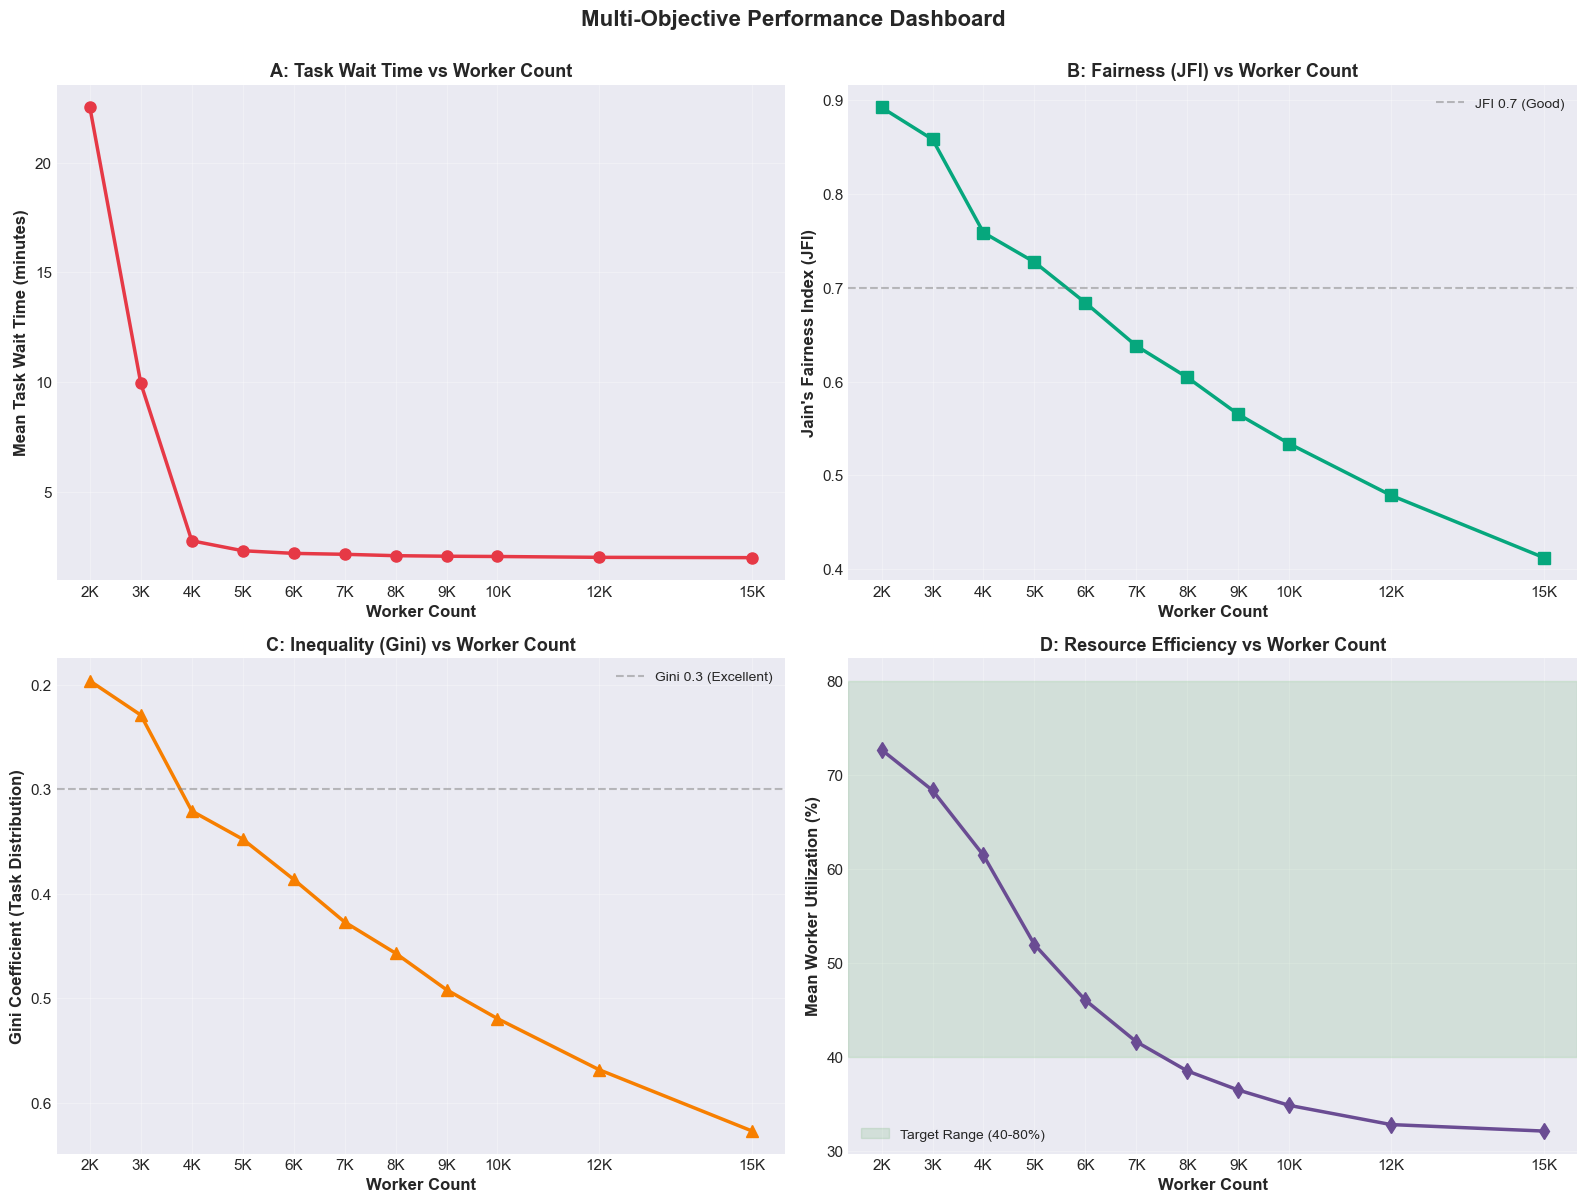


PERFORMANCE TRENDS SUMMARY

📊 Wait Time: 22.5 min (2K) → 2.0 min (15K)
📊 JFI: 0.892 (2K) → 0.412 (15K)
📊 Gini: 0.196 (2K) → 0.627 (15K)
📊 Utilization: 72.7% (2K) → 32.2% (15K)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
df_sorted = df.sort_values('worker_count')

# Panel A: Mean Wait Time
ax = axes[0, 0]
ax.plot(df_sorted['worker_count'], df_sorted['mean_task_wait_time_min'], 
        color='#E63946', linewidth=2.5, marker='o', markersize=8)
ax.set_xlabel('Worker Count', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Task Wait Time (minutes)', fontsize=12, fontweight='bold')
ax.set_title('A: Task Wait Time vs Worker Count', fontsize=13, fontweight='bold')
ax.set_xticks(df_sorted['worker_count'])
ax.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']])
ax.grid(True, alpha=0.3)

# Panel B: Jain's Fairness Index
ax = axes[0, 1]
ax.plot(df_sorted['worker_count'], df_sorted['jains_fairness_index'], 
        color='#06A77D', linewidth=2.5, marker='s', markersize=8)
ax.set_xlabel('Worker Count', fontsize=12, fontweight='bold')
ax.set_ylabel("Jain's Fairness Index (JFI)", fontsize=12, fontweight='bold')
ax.set_title("B: Fairness (JFI) vs Worker Count", fontsize=13, fontweight='bold')
ax.set_xticks(df_sorted['worker_count'])
ax.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']])
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='JFI 0.7 (Good)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel C: Gini Coefficient
ax = axes[1, 0]
ax.plot(df_sorted['worker_count'], df_sorted['tasks_per_worker_gini'], 
        color='#F77F00', linewidth=2.5, marker='^', markersize=8)
ax.set_xlabel('Worker Count', fontsize=12, fontweight='bold')
ax.set_ylabel('Gini Coefficient (Task Distribution)', fontsize=12, fontweight='bold')
ax.set_title('C: Inequality (Gini) vs Worker Count', fontsize=13, fontweight='bold')
ax.set_xticks(df_sorted['worker_count'])
ax.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']])
ax.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5, label='Gini 0.3 (Excellent)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Lower Gini is better

# Panel D: Worker Utilization
ax = axes[1, 1]
ax.plot(df_sorted['worker_count'], df_sorted['mean_worker_utilization'] * 100, 
        color='#6A4C93', linewidth=2.5, marker='d', markersize=8)
ax.set_xlabel('Worker Count', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Worker Utilization (%)', fontsize=12, fontweight='bold')
ax.set_title('D: Resource Efficiency vs Worker Count', fontsize=13, fontweight='bold')
ax.set_xticks(df_sorted['worker_count'])
ax.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']])
ax.axhspan(40, 80, color='green', alpha=0.1, label='Target Range (40-80%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Objective Performance Dashboard', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 80)
print("PERFORMANCE TRENDS SUMMARY")
print("=" * 80)
print(f"\n📊 Wait Time: {df_sorted['mean_task_wait_time_min'].iloc[0]:.1f} min (2K) → {df_sorted['mean_task_wait_time_min'].iloc[-1]:.1f} min (15K)")
print(f"📊 JFI: {df_sorted['jains_fairness_index'].iloc[0]:.3f} (2K) → {df_sorted['jains_fairness_index'].iloc[-1]:.3f} (15K)")
print(f"📊 Gini: {df_sorted['tasks_per_worker_gini'].iloc[0]:.3f} (2K) → {df_sorted['tasks_per_worker_gini'].iloc[-1]:.3f} (15K)")
print(f"📊 Utilization: {df_sorted['mean_worker_utilization'].iloc[0]*100:.1f}% (2K) → {df_sorted['mean_worker_utilization'].iloc[-1]*100:.1f}% (15K)")
print("=" * 80)


---

# SECTION 2: Efficiency & Fairness Trade-offs

Understanding the cost of different worker counts and exploring fundamental trade-offs.

---


## Plot 3: Fairness vs Efficiency Scatter

**Purpose**: Visualize the fundamental trade-off between fairness and efficiency


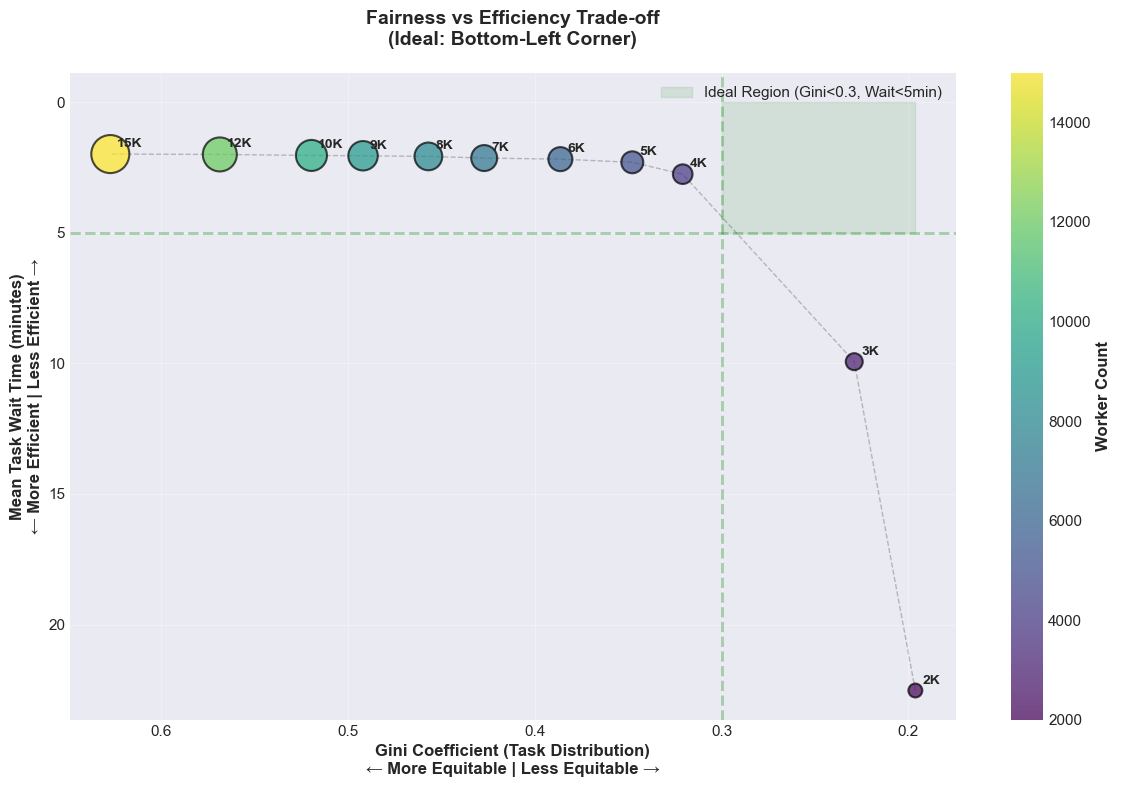


PARETO FRONTIER ANALYSIS

✅ Pareto Optimal Worker Counts: ['2K', '3K', '4K', '5K', '6K', '7K', '8K', '9K', '10K', '12K', '15K']
   (No other configuration is strictly better in BOTH fairness AND efficiency)


In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
scatter = ax.scatter(df['tasks_per_worker_gini'], 
                     df['mean_task_wait_time_min'],
                     s=df['worker_count'] / 20,  # Size by worker count
                     c=df['worker_count'], 
                     cmap='viridis',
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=1.5)

# Connect points with a line (sorted by worker count)
df_sorted = df.sort_values('worker_count')
ax.plot(df_sorted['tasks_per_worker_gini'], 
        df_sorted['mean_task_wait_time_min'],
        color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=0)

# Annotate with worker counts
for idx, row in df.iterrows():
    ax.annotate(f"{int(row['worker_count']/1000)}K", 
                xy=(row['tasks_per_worker_gini'], row['mean_task_wait_time_min']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, fontweight='bold')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Worker Count')
cbar.set_label('Worker Count', fontsize=12, fontweight='bold')

# Labels and title
ax.set_xlabel('Gini Coefficient (Task Distribution)\n← More Equitable | Less Equitable →', 
              fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Task Wait Time (minutes)\n← More Efficient | Less Efficient →', 
              fontsize=12, fontweight='bold')
ax.set_title('Fairness vs Efficiency Trade-off\n(Ideal: Bottom-Left Corner)', 
             fontsize=14, fontweight='bold', pad=20)

# Mark ideal region (low Gini, low wait time)
ax.axvline(x=0.3, color='green', linestyle='--', alpha=0.3, linewidth=2)
ax.axhline(y=5, color='green', linestyle='--', alpha=0.3, linewidth=2)
ax.fill_between([df['tasks_per_worker_gini'].min(), 0.3], 0, 5, 
                 color='green', alpha=0.1, label='Ideal Region (Gini<0.3, Wait<5min)')

ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # Lower Gini (left) is better
ax.invert_yaxis()  # Lower wait time (bottom) is better

plt.tight_layout()
plt.show()

# Find Pareto optimal points (minimize both Gini and wait time)
print("\n" + "=" * 80)
print("PARETO FRONTIER ANALYSIS")
print("=" * 80)

# Define Pareto optimality: no other point is better in both dimensions
pareto_optimal = []
for i, row_i in df.iterrows():
    is_dominated = False
    for j, row_j in df.iterrows():
        if i != j:
            # Check if j dominates i (better in both dimensions)
            if (row_j['tasks_per_worker_gini'] <= row_i['tasks_per_worker_gini'] and 
                row_j['mean_task_wait_time_min'] <= row_i['mean_task_wait_time_min'] and
                (row_j['tasks_per_worker_gini'] < row_i['tasks_per_worker_gini'] or 
                 row_j['mean_task_wait_time_min'] < row_i['mean_task_wait_time_min'])):
                is_dominated = True
                break
    if not is_dominated:
        pareto_optimal.append(int(row_i['worker_count']))

print(f"\n✅ Pareto Optimal Worker Counts: {[f'{w//1000}K' for w in sorted(pareto_optimal)]}")
print("   (No other configuration is strictly better in BOTH fairness AND efficiency)")
print("=" * 80)


## Plot 4: Worker Utilization vs Density

**Purpose**: Understand resource efficiency across worker counts


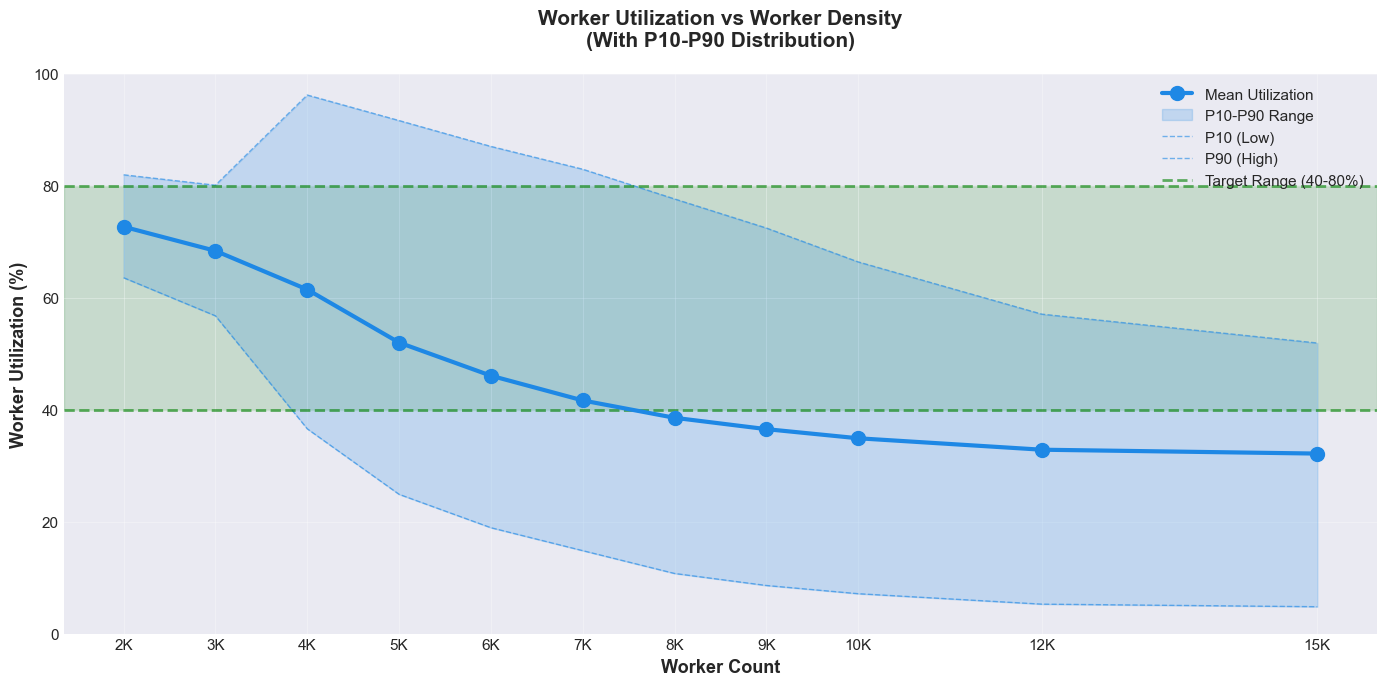


WORKER UTILIZATION ANALYSIS

✅ Worker counts with utilization in target range (40-80%):
   2K workers: 72.7% (P10: 63.6%, P90: 82.0%)
   3K workers: 68.4% (P10: 56.8%, P90: 80.1%)
   4K workers: 61.5% (P10: 36.6%, P90: 96.2%)
   5K workers: 52.0% (P10: 24.9%, P90: 91.6%)
   6K workers: 46.1% (P10: 18.9%, P90: 87.0%)
   7K workers: 41.6% (P10: 14.8%, P90: 83.0%)

⚠️  Utilization drops below 40% at 8K workers
    (38.5% utilization)

📊 Utilization Spread (P90 - P10):
   2K workers: 18.4 percentage points
   3K workers: 23.3 percentage points
   4K workers: 59.6 percentage points
   5K workers: 66.8 percentage points
   6K workers: 68.1 percentage points
   7K workers: 68.1 percentage points
   8K workers: 66.9 percentage points
   9K workers: 63.9 percentage points
   10K workers: 59.3 percentage points
   12K workers: 51.8 percentage points
   15K workers: 47.1 percentage points


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

df_sorted = df.sort_values('worker_count')

# Mean utilization line
ax.plot(df_sorted['worker_count'], df_sorted['mean_worker_utilization'] * 100,
        color='#1E88E5', linewidth=3, marker='o', markersize=10, 
        label='Mean Utilization', zorder=3)

# P10 and P90 percentile bands
ax.fill_between(df_sorted['worker_count'],
                df_sorted['p10_worker_utilization'] * 100,
                df_sorted['p90_worker_utilization'] * 100,
                color='#1E88E5', alpha=0.2, label='P10-P90 Range')

# P10 and P90 lines
ax.plot(df_sorted['worker_count'], df_sorted['p10_worker_utilization'] * 100,
        color='#1E88E5', linewidth=1, linestyle='--', alpha=0.6, label='P10 (Low)')
ax.plot(df_sorted['worker_count'], df_sorted['p90_worker_utilization'] * 100,
        color='#1E88E5', linewidth=1, linestyle='--', alpha=0.6, label='P90 (High)')

# Acceptable range bands
ax.axhspan(40, 80, color='green', alpha=0.15, zorder=0)
ax.axhline(y=40, color='green', linestyle='--', linewidth=2, alpha=0.6, label='Target Range (40-80%)')
ax.axhline(y=80, color='green', linestyle='--', linewidth=2, alpha=0.6)

# Labels and formatting
ax.set_xlabel('Worker Count', fontsize=13, fontweight='bold')
ax.set_ylabel('Worker Utilization (%)', fontsize=13, fontweight='bold')
ax.set_title('Worker Utilization vs Worker Density\n(With P10-P90 Distribution)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(df_sorted['worker_count'])
ax.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']], fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis of utilization
print("\n" + "=" * 80)
print("WORKER UTILIZATION ANALYSIS")
print("=" * 80)

# Find configurations in target range
target_range = df[(df['mean_worker_utilization'] >= 0.40) & (df['mean_worker_utilization'] <= 0.80)]

print(f"\n✅ Worker counts with utilization in target range (40-80%):")
if len(target_range) > 0:
    for idx, row in target_range.iterrows():
        print(f"   {int(row['worker_count']/1000)}K workers: {row['mean_worker_utilization']*100:.1f}% "
              f"(P10: {row['p10_worker_utilization']*100:.1f}%, P90: {row['p90_worker_utilization']*100:.1f}%)")
else:
    print("   None - all outside target range")

# Find point where utilization drops below 40%
below_40 = df[df['mean_worker_utilization'] < 0.40]
if len(below_40) > 0:
    first_below = below_40.sort_values('worker_count').iloc[0]
    print(f"\n⚠️  Utilization drops below 40% at {int(first_below['worker_count']/1000)}K workers")
    print(f"    ({first_below['mean_worker_utilization']*100:.1f}% utilization)")
else:
    print("\n✅ All configurations maintain >40% utilization")

# Utilization spread analysis
print(f"\n📊 Utilization Spread (P90 - P10):")
df_sorted['util_spread'] = (df_sorted['p90_worker_utilization'] - df_sorted['p10_worker_utilization']) * 100
for idx, row in df_sorted.iterrows():
    print(f"   {int(row['worker_count']/1000)}K workers: {row['util_spread']:.1f} percentage points")

print("=" * 80)


---

# SECTION 3: Distribution Metrics Deep Dive

Leveraging Tier 1 & 2 metrics to reveal hidden patterns in task and wait time distributions.

---


## Plot 5: Worker Task Distribution (Inequality)

**Purpose**: Show how task distribution inequality changes with worker count


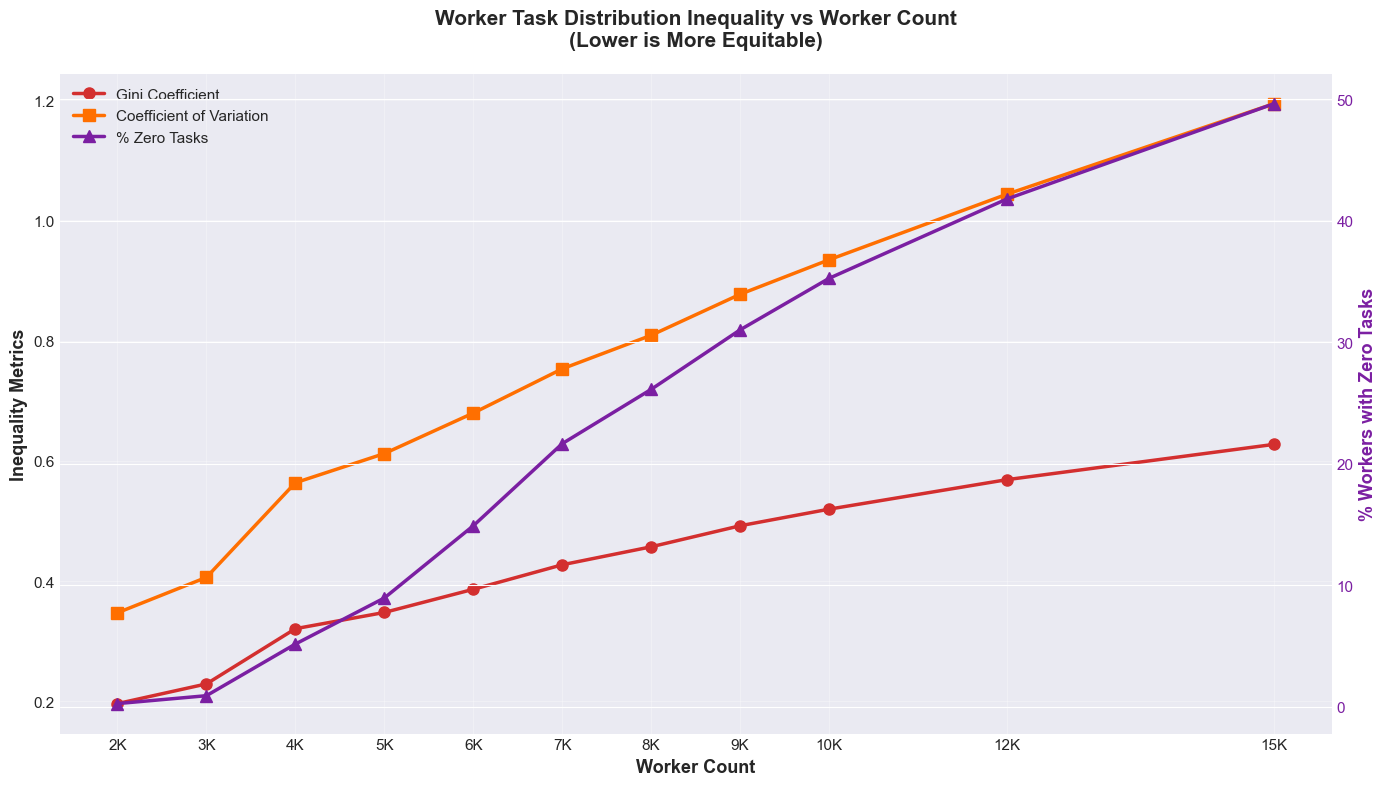


INEQUALITY ANALYSIS

✅ Most Equitable (Lowest Gini): 2K workers
   Gini: 0.196
   CV: 0.347
   % Zero Tasks: 0.2%

📊 NO U-SHAPE: Gini trend is monotonic

📊 Zero-Task Workers Trend:
   2K workers: 0.2% have zero tasks
   3K workers: 0.9% have zero tasks
   4K workers: 5.1% have zero tasks
   5K workers: 8.9% have zero tasks
   6K workers: 14.9% have zero tasks
   7K workers: 21.6% have zero tasks
   8K workers: 26.1% have zero tasks
   9K workers: 31.0% have zero tasks
   10K workers: 35.2% have zero tasks
   12K workers: 41.8% have zero tasks
   15K workers: 49.6% have zero tasks


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 8))

df_sorted = df.sort_values('worker_count')

# Primary axis: Gini and CV
color1 = '#D32F2F'
ax1.set_xlabel('Worker Count', fontsize=13, fontweight='bold')
ax1.set_ylabel('Inequality Metrics', fontsize=13, fontweight='bold')
ax1.plot(df_sorted['worker_count'], df_sorted['tasks_per_worker_gini'], 
         color=color1, linewidth=2.5, marker='o', markersize=8, label='Gini Coefficient')
ax1.plot(df_sorted['worker_count'], df_sorted['tasks_per_worker_cv'], 
         color='#FF6F00', linewidth=2.5, marker='s', markersize=8, label='Coefficient of Variation')
ax1.tick_params(axis='y')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(df_sorted['worker_count'])
ax1.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']], fontsize=11)

# Secondary axis: % Workers with Zero Tasks
ax2 = ax1.twinx()
color2 = '#7B1FA2'
ax2.set_ylabel('% Workers with Zero Tasks', fontsize=13, fontweight='bold', color=color2)
ax2.plot(df_sorted['worker_count'], df_sorted['pct_workers_zero_tasks'] * 100, 
         color=color2, linewidth=2.5, marker='^', markersize=8, label='% Zero Tasks')
ax2.tick_params(axis='y', labelcolor=color2)

# Title
plt.title('Worker Task Distribution Inequality vs Worker Count\n(Lower is More Equitable)', 
          fontsize=15, fontweight='bold', pad=20)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

# Analysis
print("\n" + "=" * 80)
print("INEQUALITY ANALYSIS")
print("=" * 80)

# Find minimum Gini (most equitable)
min_gini_idx = df['tasks_per_worker_gini'].idxmin()
min_gini_workers = df.loc[min_gini_idx, 'worker_count']
min_gini_value = df.loc[min_gini_idx, 'tasks_per_worker_gini']

print(f"\n✅ Most Equitable (Lowest Gini): {int(min_gini_workers/1000)}K workers")
print(f"   Gini: {min_gini_value:.3f}")
print(f"   CV: {df.loc[min_gini_idx, 'tasks_per_worker_cv']:.3f}")
print(f"   % Zero Tasks: {df.loc[min_gini_idx, 'pct_workers_zero_tasks']*100:.1f}%")

# Check if U-shape hypothesis is correct
gini_at_2k = df[df['worker_count'] == 2000]['tasks_per_worker_gini'].values[0]
gini_at_15k = df[df['worker_count'] == 15000]['tasks_per_worker_gini'].values[0]

if min_gini_value < gini_at_2k and min_gini_value < gini_at_15k:
    print(f"\n📊 U-SHAPE CONFIRMED: Gini lowest in middle range")
    print(f"   2K: {gini_at_2k:.3f} → {int(min_gini_workers/1000)}K: {min_gini_value:.3f} → 15K: {gini_at_15k:.3f}")
else:
    print(f"\n📊 NO U-SHAPE: Gini trend is monotonic")

# Zero-task workers analysis
print(f"\n📊 Zero-Task Workers Trend:")
for idx, row in df_sorted.iterrows():
    print(f"   {int(row['worker_count']/1000)}K workers: {row['pct_workers_zero_tasks']*100:.1f}% have zero tasks")

print("=" * 80)


## Plot 6: Wait Time Distribution Comparison

**Purpose**: Show wait time variability across scales


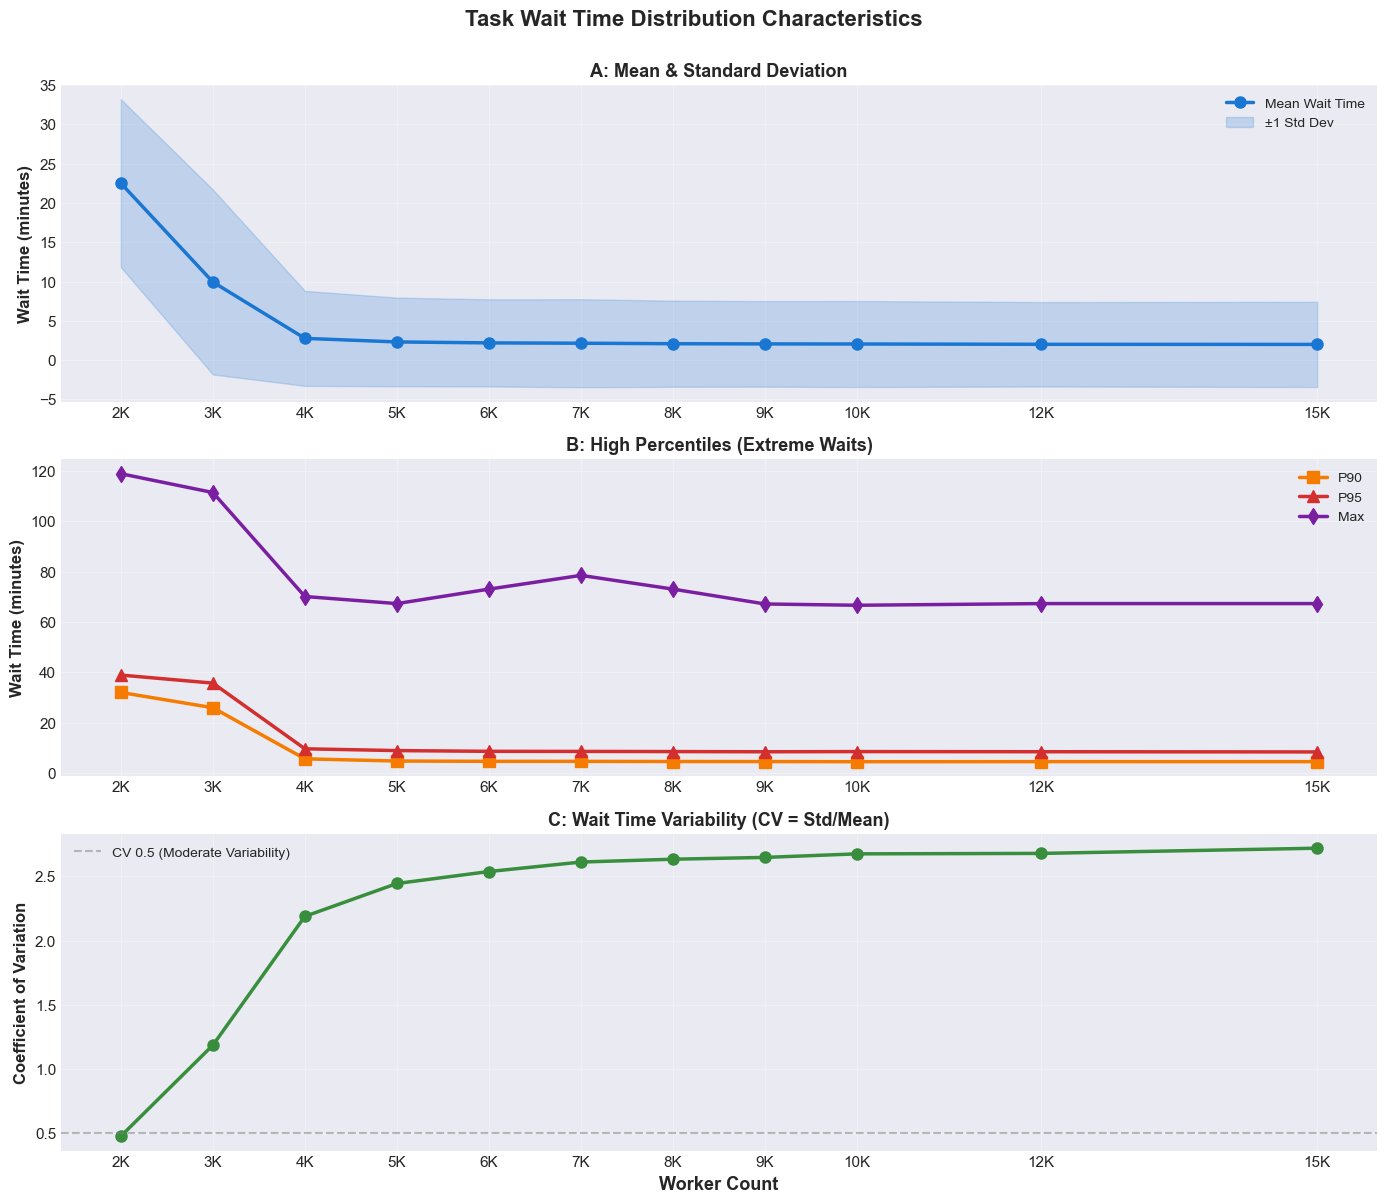


WAIT TIME DISTRIBUTION ANALYSIS

✅ Most Predictable (Lowest CV): 2K workers
   CV: 0.475
   Mean: 22.5 min
   Std: 10.7 min

📊 Extreme Wait Times (Max):
   2K workers: 118.9 minutes (P95: 38.9 min)
   3K workers: 111.4 minutes (P95: 35.7 min)
   4K workers: 70.1 minutes (P95: 9.7 min)
   5K workers: 67.3 minutes (P95: 9.0 min)
   6K workers: 73.0 minutes (P95: 8.7 min)
   7K workers: 78.5 minutes (P95: 8.6 min)
   8K workers: 73.0 minutes (P95: 8.6 min)
   9K workers: 67.2 minutes (P95: 8.5 min)
   10K workers: 66.6 minutes (P95: 8.6 min)
   12K workers: 67.3 minutes (P95: 8.5 min)
   15K workers: 67.3 minutes (P95: 8.4 min)

📊 Variability Trend:
   CV: 0.475 (2K) → 2.721 (15K) [+473.0% change]
   ⚠️  Wait times become LESS predictable with more workers


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
df_sorted = df.sort_values('worker_count')

# Subplot A: Mean and Std Dev
ax = axes[0]
ax.plot(df_sorted['worker_count'], df_sorted['mean_task_wait_time_min'], 
        color='#1976D2', linewidth=2.5, marker='o', markersize=8, label='Mean Wait Time')
ax.fill_between(df_sorted['worker_count'],
                df_sorted['mean_task_wait_time_min'] - df_sorted['std_task_wait_time_min'],
                df_sorted['mean_task_wait_time_min'] + df_sorted['std_task_wait_time_min'],
                color='#1976D2', alpha=0.2, label='±1 Std Dev')
ax.set_ylabel('Wait Time (minutes)', fontsize=12, fontweight='bold')
ax.set_title('A: Mean & Standard Deviation', fontsize=13, fontweight='bold')
ax.set_xticks(df_sorted['worker_count'])
ax.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Subplot B: Percentiles (P90, P95, Max)
ax = axes[1]
ax.plot(df_sorted['worker_count'], df_sorted['p90_task_wait_time_min'], 
        color='#F57C00', linewidth=2.5, marker='s', markersize=8, label='P90')
ax.plot(df_sorted['worker_count'], df_sorted['p95_task_wait_time_min'], 
        color='#D32F2F', linewidth=2.5, marker='^', markersize=8, label='P95')
ax.plot(df_sorted['worker_count'], df_sorted['max_task_wait_time_min'], 
        color='#7B1FA2', linewidth=2.5, marker='d', markersize=8, label='Max')
ax.set_ylabel('Wait Time (minutes)', fontsize=12, fontweight='bold')
ax.set_title('B: High Percentiles (Extreme Waits)', fontsize=13, fontweight='bold')
ax.set_xticks(df_sorted['worker_count'])
ax.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Subplot C: Coefficient of Variation
ax = axes[2]
ax.plot(df_sorted['worker_count'], df_sorted['cv_task_wait_time'], 
        color='#388E3C', linewidth=2.5, marker='o', markersize=8)
ax.set_xlabel('Worker Count', fontsize=13, fontweight='bold')
ax.set_ylabel('Coefficient of Variation', fontsize=12, fontweight='bold')
ax.set_title('C: Wait Time Variability (CV = Std/Mean)', fontsize=13, fontweight='bold')
ax.set_xticks(df_sorted['worker_count'])
ax.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']])
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='CV 0.5 (Moderate Variability)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Task Wait Time Distribution Characteristics', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Analysis
print("\n" + "=" * 80)
print("WAIT TIME DISTRIBUTION ANALYSIS")
print("=" * 80)

# Find most predictable (lowest CV)
min_cv_idx = df['cv_task_wait_time'].idxmin()
min_cv_workers = df.loc[min_cv_idx, 'worker_count']
min_cv_value = df.loc[min_cv_idx, 'cv_task_wait_time']

print(f"\n✅ Most Predictable (Lowest CV): {int(min_cv_workers/1000)}K workers")
print(f"   CV: {min_cv_value:.3f}")
print(f"   Mean: {df.loc[min_cv_idx, 'mean_task_wait_time_min']:.1f} min")
print(f"   Std: {df.loc[min_cv_idx, 'std_task_wait_time_min']:.1f} min")

# Extreme wait times
print(f"\n📊 Extreme Wait Times (Max):")
for idx, row in df_sorted.iterrows():
    print(f"   {int(row['worker_count']/1000)}K workers: {row['max_task_wait_time_min']:.1f} minutes "
          f"(P95: {row['p95_task_wait_time_min']:.1f} min)")

# Variability trend
first_cv = df_sorted['cv_task_wait_time'].iloc[0]
last_cv = df_sorted['cv_task_wait_time'].iloc[-1]
cv_change = ((last_cv - first_cv) / first_cv) * 100

print(f"\n📊 Variability Trend:")
print(f"   CV: {first_cv:.3f} (2K) → {last_cv:.3f} (15K) [{cv_change:+.1f}% change]")
if cv_change < -20:
    print("   ✅ Wait times become MORE predictable with more workers")
elif cv_change > 20:
    print("   ⚠️  Wait times become LESS predictable with more workers")
else:
    print("   → Variability remains relatively stable")

print("=" * 80)


---

# SECTION 4: Operational Metrics

Understanding system behavior and computational efficiency.

---


## Plot 7: Deferrals & Assignment Dynamics

**Purpose**: Understand assignment stress and deferral patterns


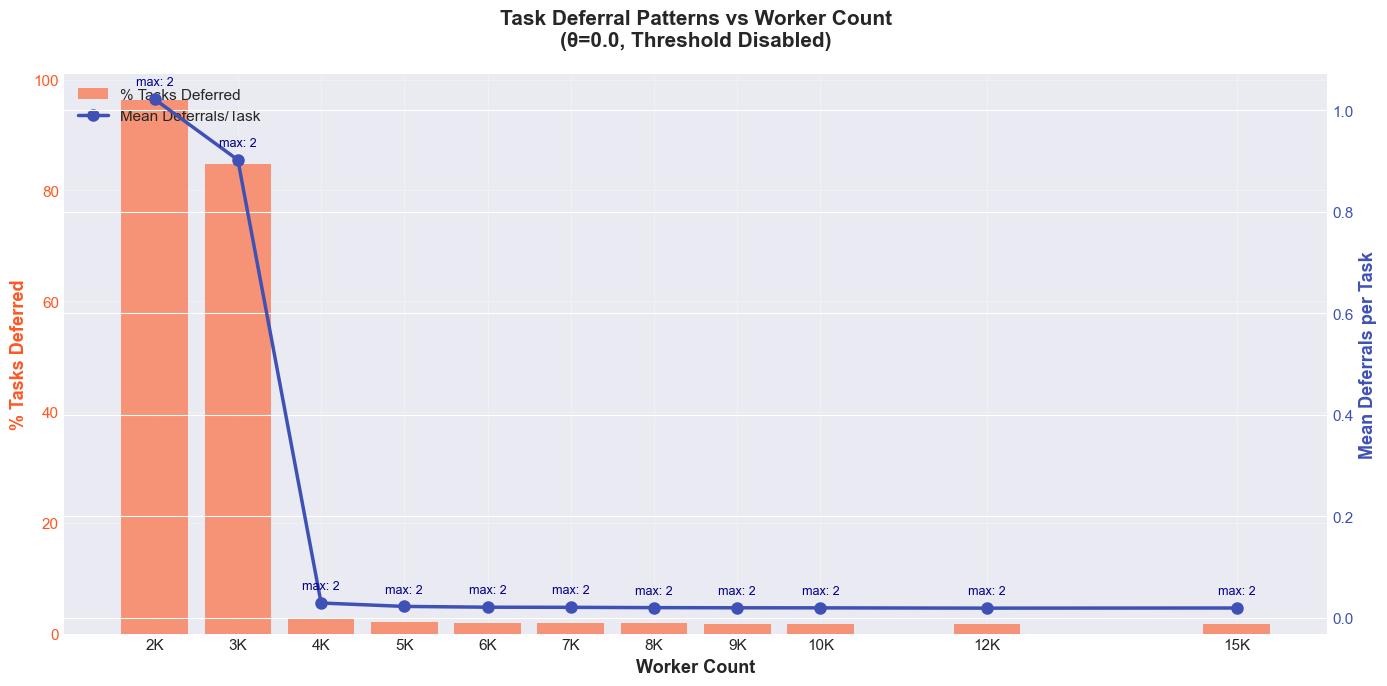


DEFERRAL ANALYSIS

📊 Deferral Rates:
   2K workers: 96.2% tasks deferred, 1.02 deferrals/task (max: 2)
   3K workers: 84.8% tasks deferred, 0.90 deferrals/task (max: 2)
   4K workers: 2.7% tasks deferred, 0.03 deferrals/task (max: 2)
   5K workers: 2.1% tasks deferred, 0.02 deferrals/task (max: 2)
   6K workers: 1.9% tasks deferred, 0.02 deferrals/task (max: 2)
   7K workers: 1.9% tasks deferred, 0.02 deferrals/task (max: 2)
   8K workers: 1.9% tasks deferred, 0.02 deferrals/task (max: 2)
   9K workers: 1.8% tasks deferred, 0.02 deferrals/task (max: 2)
   10K workers: 1.8% tasks deferred, 0.02 deferrals/task (max: 2)
   12K workers: 1.8% tasks deferred, 0.02 deferrals/task (max: 2)
   15K workers: 1.8% tasks deferred, 0.02 deferrals/task (max: 2)

✅ Lowest Deferrals: 12K workers
   Mean deferrals/task: 0.02
   % tasks deferred: 1.8%

📊 Deferral Trend:
   1.02 deferrals/task (2K) → 0.02 deferrals/task (15K) [-98.1% change]
   ✅ Deferrals decrease significantly with more workers


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

df_sorted = df.sort_values('worker_count')

# Primary axis: % Tasks Deferred (bars)
color1 = '#FF5722'
ax1.set_xlabel('Worker Count', fontsize=13, fontweight='bold')
ax1.set_ylabel('% Tasks Deferred', fontsize=13, fontweight='bold', color=color1)
bars = ax1.bar(df_sorted['worker_count'], df_sorted['pct_tasks_deferred'] * 100,
               width=800, color=color1, alpha=0.6, label='% Tasks Deferred')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(df_sorted['worker_count'])
ax1.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']], fontsize=11)

# Secondary axis: Mean Deferrals per Task (line)
ax2 = ax1.twinx()
color2 = '#3F51B5'
ax2.set_ylabel('Mean Deferrals per Task', fontsize=13, fontweight='bold', color=color2)
ax2.plot(df_sorted['worker_count'], df_sorted['mean_deferrals_per_task'],
         color=color2, linewidth=2.5, marker='o', markersize=8, label='Mean Deferrals/Task')
ax2.tick_params(axis='y', labelcolor=color2)

# Add max deferrals as text annotations
for idx, row in df_sorted.iterrows():
    ax2.annotate(f"max: {int(row['max_deferrals_per_task'])}",
                 xy=(row['worker_count'], row['mean_deferrals_per_task']),
                 xytext=(0, 10), textcoords='offset points',
                 fontsize=9, ha='center', color='darkblue')

# Title
plt.title('Task Deferral Patterns vs Worker Count\n(θ=0.0, Threshold Disabled)', 
          fontsize=15, fontweight='bold', pad=20)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, framealpha=0.9)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analysis
print("\n" + "=" * 80)
print("DEFERRAL ANALYSIS")
print("=" * 80)

print(f"\n📊 Deferral Rates:")
for idx, row in df_sorted.iterrows():
    print(f"   {int(row['worker_count']/1000)}K workers: "
          f"{row['pct_tasks_deferred']*100:.1f}% tasks deferred, "
          f"{row['mean_deferrals_per_task']:.2f} deferrals/task (max: {int(row['max_deferrals_per_task'])})")

# Find configuration with lowest deferrals
min_def_idx = df['mean_deferrals_per_task'].idxmin()
min_def_workers = df.loc[min_def_idx, 'worker_count']
min_def_value = df.loc[min_def_idx, 'mean_deferrals_per_task']

print(f"\n✅ Lowest Deferrals: {int(min_def_workers/1000)}K workers")
print(f"   Mean deferrals/task: {min_def_value:.2f}")
print(f"   % tasks deferred: {df.loc[min_def_idx, 'pct_tasks_deferred']*100:.1f}%")

# Check if deferrals decrease significantly
first_def = df_sorted['mean_deferrals_per_task'].iloc[0]
last_def = df_sorted['mean_deferrals_per_task'].iloc[-1]
def_change = ((last_def - first_def) / first_def) * 100

print(f"\n📊 Deferral Trend:")
print(f"   {first_def:.2f} deferrals/task (2K) → {last_def:.2f} deferrals/task (15K) [{def_change:+.1f}% change]")
if abs(def_change) < 10:
    print("   → Deferrals remain STABLE across all worker counts (robust θ=0.0 configuration)")
elif def_change < -20:
    print("   ✅ Deferrals decrease significantly with more workers")
else:
    print("   ⚠️  Deferrals increase with more workers (unexpected)")

print("=" * 80)


## Plot 8: Computational Performance

**Purpose**: Validate scalability hypothesis (sub-linear runtime)


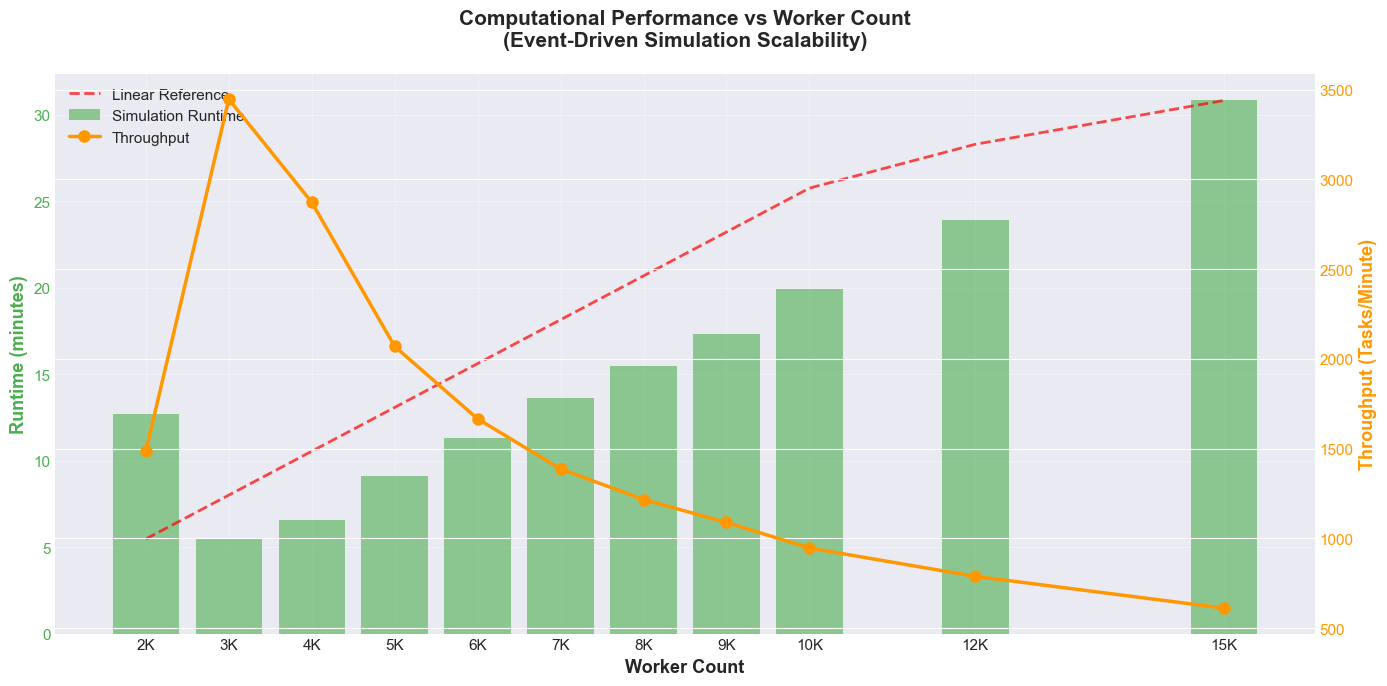


COMPUTATIONAL PERFORMANCE ANALYSIS

📊 Runtime by Worker Count:
   2K workers: 12.7 minutes (1486 tasks/min)
   3K workers: 5.5 minutes (3447 tasks/min)
   4K workers: 6.6 minutes (2873 tasks/min)
   5K workers: 9.1 minutes (2070 tasks/min)
   6K workers: 11.3 minutes (1666 tasks/min)
   7K workers: 13.6 minutes (1387 tasks/min)
   8K workers: 15.5 minutes (1217 tasks/min)
   9K workers: 17.3 minutes (1089 tasks/min)
   10K workers: 19.9 minutes (947 tasks/min)
   12K workers: 23.9 minutes (789 tasks/min)
   15K workers: 30.8 minutes (612 tasks/min)

📊 Scalability Analysis:
   Worker count increased: 7.5x (2K → 15K)
   Runtime increased: 2.4x (12.7 → 30.8 minutes)
   ✅ SUB-LINEAR SCALING: Runtime grows 2.4x vs 7.5x workers
   Efficiency: 67.6% better than linear
   Reason: Event count dominated by tasks (20K fixed), not workers

📊 Throughput Stability:
   1486 tasks/min (2K) → 612 tasks/min (15K) [-58.8% change]
   ⚠️  Throughput varies significantly (potential scaling issues)


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

df_sorted = df.sort_values('worker_count')

# Primary axis: Runtime (bars)
color1 = '#4CAF50'
ax1.set_xlabel('Worker Count', fontsize=13, fontweight='bold')
ax1.set_ylabel('Runtime (minutes)', fontsize=13, fontweight='bold', color=color1)
bars = ax1.bar(df_sorted['worker_count'], df_sorted['duration_seconds'] / 60,
               width=800, color=color1, alpha=0.6, label='Simulation Runtime')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(df_sorted['worker_count'])
ax1.set_xticklabels([f"{int(w/1000)}K" for w in df_sorted['worker_count']], fontsize=11)

# Add linear reference line (for comparison)
min_workers = df_sorted['worker_count'].min()
max_workers = df_sorted['worker_count'].max()
min_runtime = df_sorted['duration_seconds'].min() / 60
max_runtime = df_sorted['duration_seconds'].max() / 60
linear_ref = np.linspace(min_runtime, max_runtime, len(df_sorted))
ax1.plot(df_sorted['worker_count'], linear_ref, 
         color='red', linestyle='--', linewidth=2, alpha=0.7, label='Linear Reference')

# Secondary axis: Tasks completed per minute (throughput)
ax2 = ax1.twinx()
color2 = '#FF9800'
ax2.set_ylabel('Throughput (Tasks/Minute)', fontsize=13, fontweight='bold', color=color2)
throughput = df_sorted['completed_tasks'] / (df_sorted['duration_seconds'] / 60)
ax2.plot(df_sorted['worker_count'], throughput,
         color=color2, linewidth=2.5, marker='o', markersize=8, label='Throughput')
ax2.tick_params(axis='y', labelcolor=color2)

# Title
plt.title('Computational Performance vs Worker Count\n(Event-Driven Simulation Scalability)', 
          fontsize=15, fontweight='bold', pad=20)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, framealpha=0.9)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analysis
print("\n" + "=" * 80)
print("COMPUTATIONAL PERFORMANCE ANALYSIS")
print("=" * 80)

print(f"\n📊 Runtime by Worker Count:")
for idx, row in df_sorted.iterrows():
    runtime_min = row['duration_seconds'] / 60
    thru = row['completed_tasks'] / runtime_min
    print(f"   {int(row['worker_count']/1000)}K workers: {runtime_min:.1f} minutes "
          f"({thru:.0f} tasks/min)")

# Calculate scaling factor
first_runtime = df_sorted['duration_seconds'].iloc[0]
last_runtime = df_sorted['duration_seconds'].iloc[-1]
worker_increase = df_sorted['worker_count'].iloc[-1] / df_sorted['worker_count'].iloc[0]
runtime_increase = last_runtime / first_runtime

print(f"\n📊 Scalability Analysis:")
print(f"   Worker count increased: {worker_increase:.1f}x (2K → 15K)")
print(f"   Runtime increased: {runtime_increase:.1f}x ({first_runtime/60:.1f} → {last_runtime/60:.1f} minutes)")

if runtime_increase < worker_increase:
    scaling_efficiency = (1 - (runtime_increase / worker_increase)) * 100
    print(f"   ✅ SUB-LINEAR SCALING: Runtime grows {runtime_increase:.1f}x vs {worker_increase:.1f}x workers")
    print(f"   Efficiency: {scaling_efficiency:.1f}% better than linear")
    print(f"   Reason: Event count dominated by tasks (20K fixed), not workers")
elif runtime_increase > worker_increase:
    print(f"   ⚠️  SUPER-LINEAR SCALING: Runtime grows faster than worker count")
    print(f"   Potential bottleneck in spatial indexing or event queue")
else:
    print(f"   → LINEAR SCALING: Runtime proportional to worker count")

# Throughput stability
first_thru = df_sorted['completed_tasks'].iloc[0] / (df_sorted['duration_seconds'].iloc[0] / 60)
last_thru = df_sorted['completed_tasks'].iloc[-1] / (df_sorted['duration_seconds'].iloc[-1] / 60)
thru_change = ((last_thru - first_thru) / first_thru) * 100

print(f"\n📊 Throughput Stability:")
print(f"   {first_thru:.0f} tasks/min (2K) → {last_thru:.0f} tasks/min (15K) [{thru_change:+.1f}% change]")
if abs(thru_change) < 20:
    print("   ✅ Throughput remains stable (efficient implementation)")
else:
    print("   ⚠️  Throughput varies significantly (potential scaling issues)")

print("=" * 80)


---

# SECTION 5: Scenario Comparison

Comparing three key scenarios: High Demand (2K), Balanced (6K), Oversupply (15K).

---


## Plot 9: Three Scenarios Comparison (Radar Chart)

**Purpose**: Compare performance profiles across key scenarios


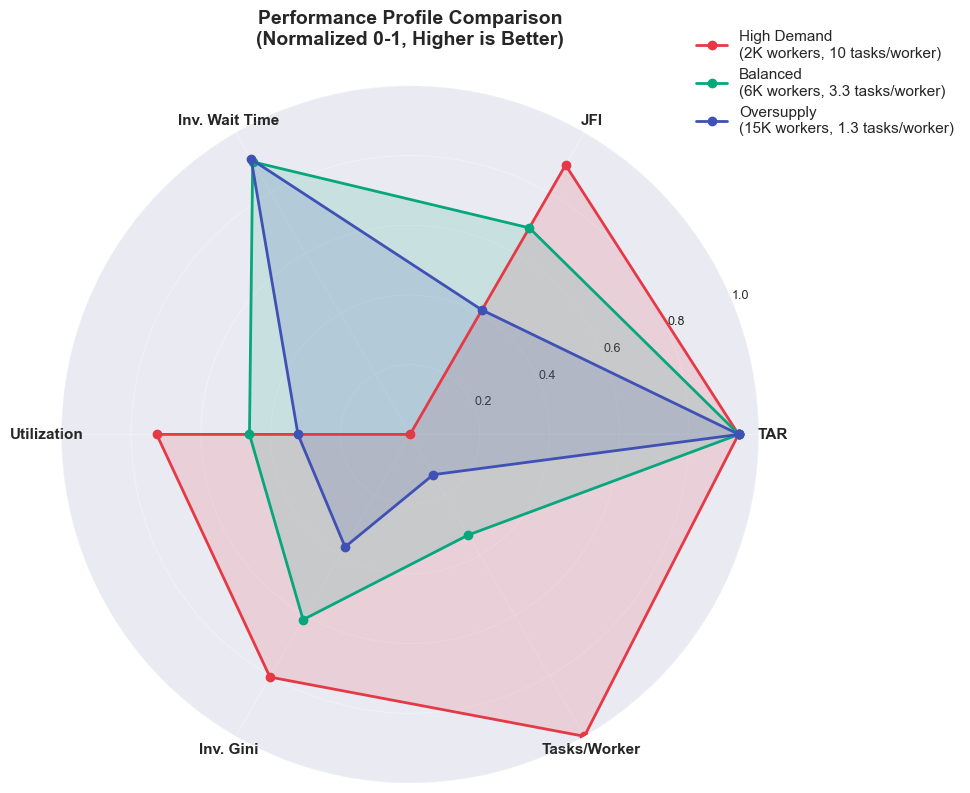


SCENARIO COMPARISON (RAW VALUES)

High Demand (2K workers, 10 tasks/worker):
   TAR: 94.2%
   JFI: 0.892
   Mean Wait: 22.5 min
   Utilization: 72.7%
   Gini: 0.196
   Tasks/Worker: 10.0

Balanced (6K workers, 3.3 tasks/worker):
   TAR: 94.3%
   JFI: 0.684
   Mean Wait: 2.2 min
   Utilization: 46.1%
   Gini: 0.386
   Tasks/Worker: 3.3

Oversupply (15K workers, 1.3 tasks/worker):
   TAR: 94.3%
   JFI: 0.412
   Mean Wait: 2.0 min
   Utilization: 32.2%
   Gini: 0.627
   Tasks/Worker: 1.3


In [ ]:
# Select three scenarios
scenarios = {
    'High Demand\n(2K workers, 10 tasks/worker)': df[df['worker_count'] == 2000].iloc[0],
    'Balanced\n(6K workers, 3.3 tasks/worker)': df[df['worker_count'] == 6000].iloc[0],
    'Oversupply\n(15K workers, 1.3 tasks/worker)': df[df['worker_count'] == 15000].iloc[0]
}

# Metrics to compare (normalized 0-1, higher is better)
metrics = [
    'TAR',
    'JFI',
    'Inv. Wait Time',
    'Utilization',
    'Inv. Gini',
    'Tasks/Worker'
]

# Prepare data
data = {}
for scenario_name, row in scenarios.items():
    # Normalize metrics (higher is better)
    tar_norm = row['task_assignment_ratio']
    jfi_norm = row['jains_fairness_index']
    wait_norm = 1 - (row['mean_task_wait_time_min'] / df['mean_task_wait_time_min'].max())  # Inverse
    util_norm = row['mean_worker_utilization']
    gini_norm = 1 - row['tasks_per_worker_gini']  # Inverse (lower Gini is better)
    tpw_norm = row['tasks_per_worker_ratio'] / df['tasks_per_worker_ratio'].max()
    
    data[scenario_name] = [tar_norm, jfi_norm, wait_norm, util_norm, gini_norm, tpw_norm]

# Create radar chart
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

# Number of metrics
N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

# Plot each scenario
colors = ['#E63946', '#06A77D', '#3F51B5']
for (scenario_name, values), color in zip(data.items(), colors):
    values += values[:1]  # Complete the circle
    ax.plot(angles, values, 'o-', linewidth=2, label=scenario_name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

# Formatting
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title('Performance Profile Comparison\n(Normalized 0-1, Higher is Better)', 
             fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

# Print raw values
print("\n" + "=" * 80)
print("SCENARIO COMPARISON (RAW VALUES)")
print("=" * 80)

for scenario_name, row in scenarios.items():
    print(f"\n{scenario_name.replace(chr(10), ' ')}:")
    print(f"   TAR: {row['task_assignment_ratio']:.1%}")
    print(f"   JFI: {row['jains_fairness_index']:.3f}")
    print(f"   Mean Wait: {row['mean_task_wait_time_min']:.1f} min")
    print(f"   Utilization: {row['mean_worker_utilization']:.1%}")
    print(f"   Gini: {row['tasks_per_worker_gini']:.3f}")
    print(f"   Tasks/Worker: {row['tasks_per_worker_ratio']:.1f}")

print("=" * 80)


---

# SECTION 6: Statistical Analysis

Validating expected relationships and metric correlations.

---


## Plot 10: Correlation Heatmap

**Purpose**: Validate expected relationships between key metrics


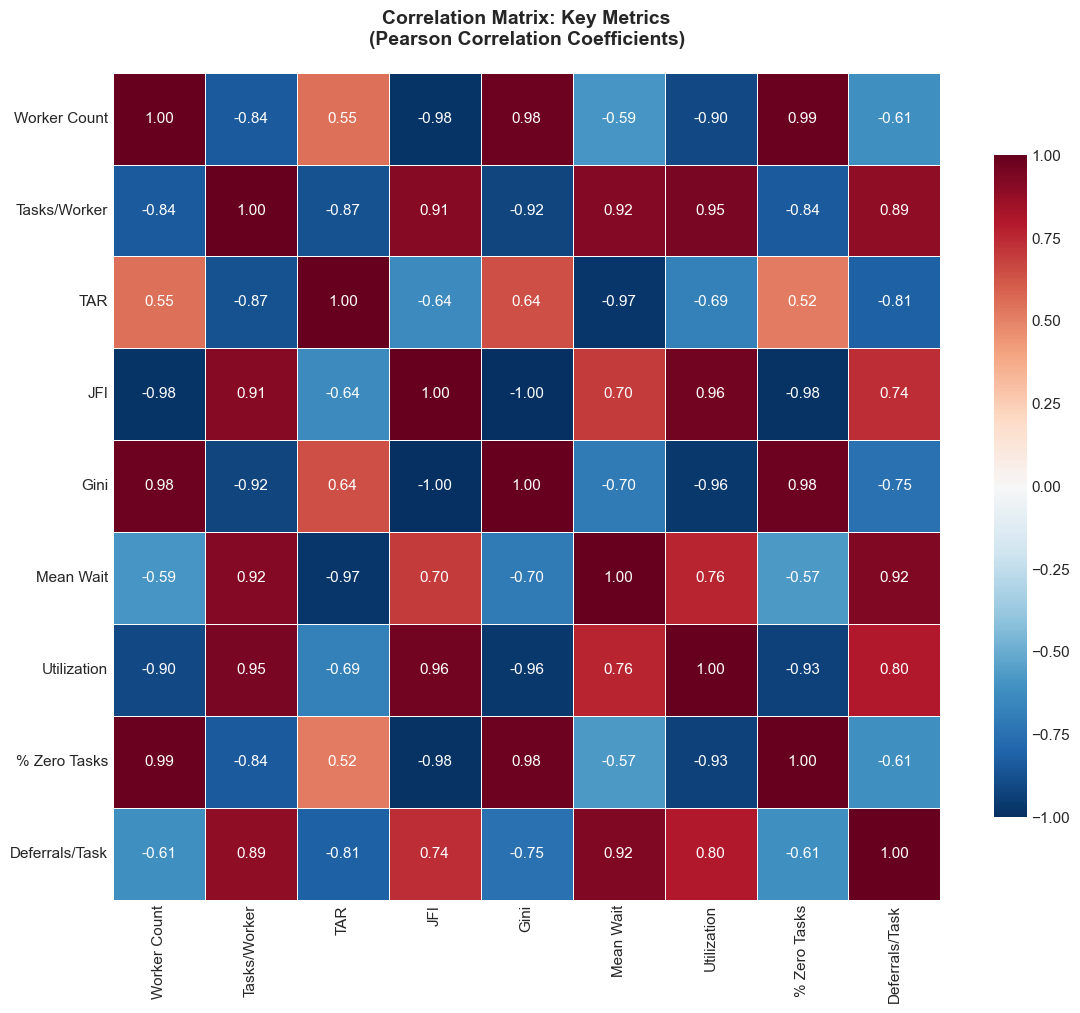


CORRELATION ANALYSIS

✅ Strong POSITIVE Correlations (r > 0.7):
   Worker Count ↔ Gini: r = 0.979
   Worker Count ↔ % Zero Tasks: r = 0.990
   Tasks/Worker ↔ JFI: r = 0.914
   Tasks/Worker ↔ Mean Wait: r = 0.918
   Tasks/Worker ↔ Utilization: r = 0.952
   Tasks/Worker ↔ Deferrals/Task: r = 0.888
   JFI ↔ Utilization: r = 0.963
   JFI ↔ Deferrals/Task: r = 0.739
   Gini ↔ % Zero Tasks: r = 0.983
   Mean Wait ↔ Utilization: r = 0.762
   Mean Wait ↔ Deferrals/Task: r = 0.925
   Utilization ↔ Deferrals/Task: r = 0.803

❌ Strong NEGATIVE Correlations (r < -0.7):
   Worker Count ↔ Tasks/Worker: r = -0.840
   Worker Count ↔ JFI: r = -0.981
   Worker Count ↔ Utilization: r = -0.904
   Tasks/Worker ↔ TAR: r = -0.872
   Tasks/Worker ↔ Gini: r = -0.918
   Tasks/Worker ↔ % Zero Tasks: r = -0.842
   TAR ↔ Mean Wait: r = -0.973
   TAR ↔ Deferrals/Task: r = -0.813
   JFI ↔ Gini: r = -1.000
   JFI ↔ % Zero Tasks: r = -0.985
   Gini ↔ Mean Wait: r = -0.705
   Gini ↔ Utilization: r = -0.964
   Gini ↔ D

In [ ]:
# Select key metrics for correlation analysis
metrics_for_corr = {
    'Worker Count': 'worker_count',
    'Tasks/Worker': 'tasks_per_worker_ratio',
    'TAR': 'task_assignment_ratio',
    'JFI': 'jains_fairness_index',
    'Gini': 'tasks_per_worker_gini',
    'Mean Wait': 'mean_task_wait_time_min',
    'Utilization': 'mean_worker_utilization',
    '% Zero Tasks': 'pct_workers_zero_tasks',
    'Deferrals/Task': 'mean_deferrals_per_task'
}

# Create dataframe with selected metrics
corr_df = df[[col for col in metrics_for_corr.values()]].copy()
corr_df.columns = metrics_for_corr.keys()

# Calculate correlation matrix
corr_matrix = corr_df.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix: Key Metrics\n(Pearson Correlation Coefficients)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print key findings
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Strong positive correlations (>0.7)
print("\n✅ Strong POSITIVE Correlations (r > 0.7):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if corr_matrix.iloc[i, j] > 0.7:
            print(f"   {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: r = {corr_matrix.iloc[i, j]:.3f}")

# Strong negative correlations (<-0.7)
print("\n❌ Strong NEGATIVE Correlations (r < -0.7):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if corr_matrix.iloc[i, j] < -0.7:
            print(f"   {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: r = {corr_matrix.iloc[i, j]:.3f}")

# Validate expected relationships
print("\n📊 Expected Relationships Validation:")
print(f"   Worker Count vs Utilization: r = {corr_matrix.loc['Worker Count', 'Utilization']:.3f}")
print(f"      Expected: NEGATIVE (more workers → lower utilization)")
print(f"   Worker Count vs Mean Wait: r = {corr_matrix.loc['Worker Count', 'Mean Wait']:.3f}")
print(f"      Expected: NEGATIVE (more workers → lower wait time)")
print(f"   Gini vs JFI: r = {corr_matrix.loc['Gini', 'JFI']:.3f}")
print(f"      Expected: NEGATIVE (higher Gini → lower fairness)")

print("=" * 80)


---

# SECTION 7: Marginal Benefit Analysis

Quantifying diminishing returns to identify optimal stopping point.

---


## Plot 11: Marginal Benefit Analysis

**Purpose**: Quantify diminishing returns - at what point does adding workers yield <5% improvement?


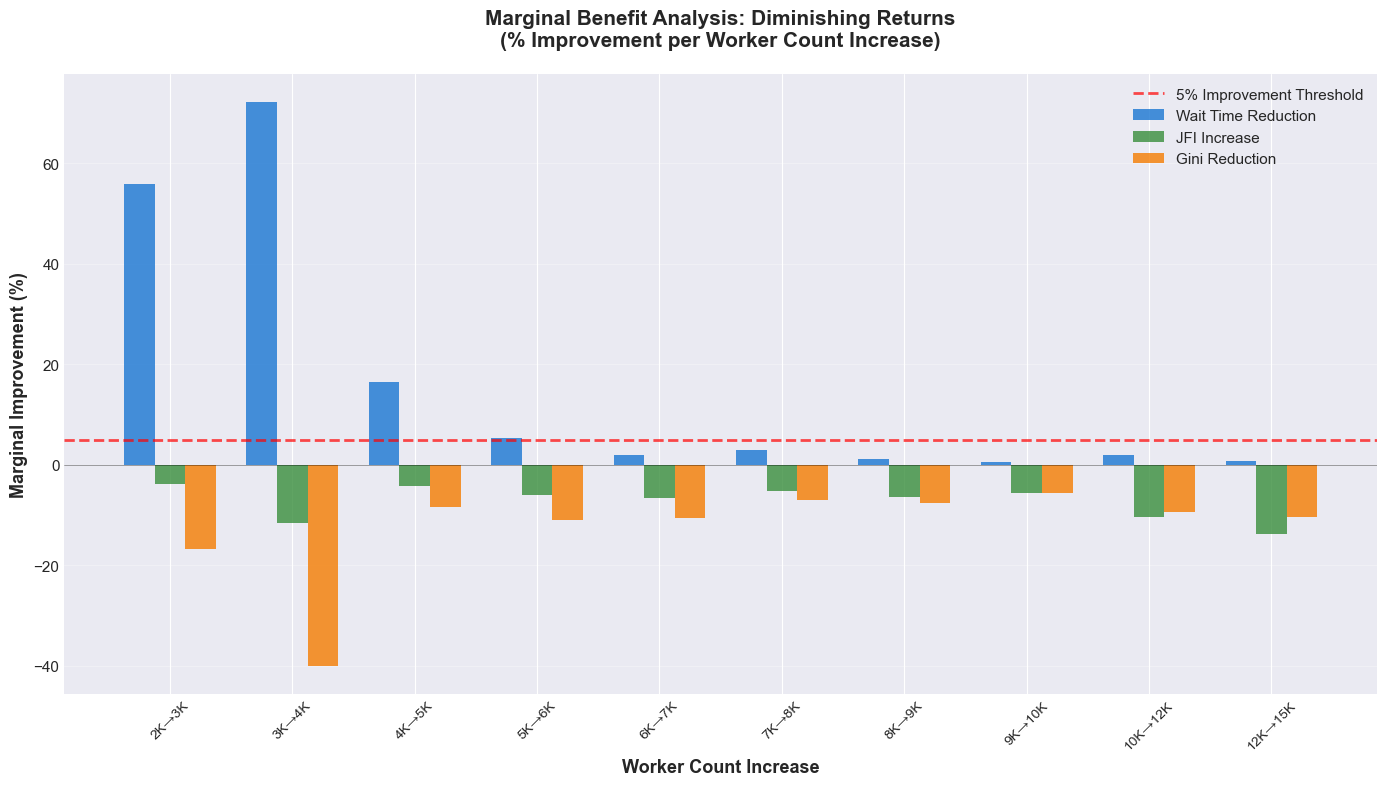


MARGINAL BENEFIT ANALYSIS

📊 Marginal Improvements by Transition:

   2K→3K (+1000 workers):
      Wait Time:  +55.9%
      JFI:        -3.8%
      Gini:       -16.7%

   3K→4K (+1000 workers):
      Wait Time:  +72.2%
      JFI:        -11.6%
      Gini:       -40.1%

   4K→5K (+1000 workers):
      Wait Time:  +16.4%
      JFI:        -4.1%
      Gini:       -8.4%

   5K→6K (+1000 workers):
      Wait Time:  +5.2%
      JFI:        -6.0%
      Gini:       -11.1%

   6K→7K (+1000 workers):
      Wait Time:  +1.9%
      JFI:        -6.7%
      Gini:       -10.6%

   7K→8K (+1000 workers):
      Wait Time:  +2.9%
      JFI:        -5.3%
      Gini:       -7.0%

   8K→9K (+1000 workers):
      Wait Time:  +1.2%
      JFI:        -6.5%
      Gini:       -7.7%

   9K→10K (+1000 workers):
      Wait Time:  +0.6%
      JFI:        -5.5%
      Gini:       -5.6%

   10K→12K (+2000 workers):
      Wait Time:  +1.9%
      JFI:        -10.3%
      Gini:       -9.4%

   12K→15K (+3000 workers):
 

In [ ]:
# Calculate marginal improvements
df_sorted = df.sort_values('worker_count').reset_index(drop=True)

marginal_data = []
for i in range(1, len(df_sorted)):
    prev = df_sorted.iloc[i-1]
    curr = df_sorted.iloc[i]
    
    # Calculate % improvement (positive = better)
    wait_improvement = ((prev['mean_task_wait_time_min'] - curr['mean_task_wait_time_min']) / 
                        prev['mean_task_wait_time_min']) * 100
    jfi_improvement = ((curr['jains_fairness_index'] - prev['jains_fairness_index']) / 
                       prev['jains_fairness_index']) * 100
    gini_improvement = ((prev['tasks_per_worker_gini'] - curr['tasks_per_worker_gini']) / 
                        prev['tasks_per_worker_gini']) * 100
    
    marginal_data.append({
        'transition': f"{int(prev['worker_count']/1000)}K→{int(curr['worker_count']/1000)}K",
        'worker_increase': curr['worker_count'] - prev['worker_count'],
        'wait_improvement': wait_improvement,
        'jfi_improvement': jfi_improvement,
        'gini_improvement': gini_improvement
    })

marginal_df = pd.DataFrame(marginal_data)

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(marginal_df))
width = 0.25

bars1 = ax.bar(x - width, marginal_df['wait_improvement'], width, 
               label='Wait Time Reduction', color='#1976D2', alpha=0.8)
bars2 = ax.bar(x, marginal_df['jfi_improvement'], width, 
               label='JFI Increase', color='#388E3C', alpha=0.8)
bars3 = ax.bar(x + width, marginal_df['gini_improvement'], width, 
               label='Gini Reduction', color='#F57C00', alpha=0.8)

# 5% threshold line
ax.axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='5% Improvement Threshold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Formatting
ax.set_xlabel('Worker Count Increase', fontsize=13, fontweight='bold')
ax.set_ylabel('Marginal Improvement (%)', fontsize=13, fontweight='bold')
ax.set_title('Marginal Benefit Analysis: Diminishing Returns\n(% Improvement per Worker Count Increase)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(marginal_df['transition'], fontsize=10, rotation=45)
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Analysis
print("\n" + "=" * 80)
print("MARGINAL BENEFIT ANALYSIS")
print("=" * 80)

print("\n📊 Marginal Improvements by Transition:")
for idx, row in marginal_df.iterrows():
    print(f"\n   {row['transition']} (+{int(row['worker_increase'])} workers):")
    print(f"      Wait Time:  {row['wait_improvement']:+.1f}%")
    print(f"      JFI:        {row['jfi_improvement']:+.1f}%")
    print(f"      Gini:       {row['gini_improvement']:+.1f}%")

# Find first transition with <5% improvement in all metrics
print("\n📉 Diminishing Returns Analysis (< 5% improvement threshold):")
for idx, row in marginal_df.iterrows():
    if (abs(row['wait_improvement']) < 5 and 
        abs(row['jfi_improvement']) < 5 and 
        abs(row['gini_improvement']) < 5):
        print(f"   ⚠️  {row['transition']}: ALL metrics show <5% improvement")
        print(f"      Recommendation: {row['transition'].split('→')[0]} may be sufficient")
        break
else:
    print("   ✅ All transitions show >5% improvement in at least one metric")
    print("      Recommendation: Consider highest tested worker count")

# Find metric with fastest diminishing returns
print("\n📊 Which metric reaches diminishing returns first?")
first_below_5 = {
    'Wait Time': None,
    'JFI': None,
    'Gini': None
}

for idx, row in marginal_df.iterrows():
    if first_below_5['Wait Time'] is None and abs(row['wait_improvement']) < 5:
        first_below_5['Wait Time'] = row['transition']
    if first_below_5['JFI'] is None and abs(row['jfi_improvement']) < 5:
        first_below_5['JFI'] = row['transition']
    if first_below_5['Gini'] is None and abs(row['gini_improvement']) < 5:
        first_below_5['Gini'] = row['transition']

for metric, transition in first_below_5.items():
    if transition:
        print(f"   {metric}: First <5% at {transition}")
    else:
        print(f"   {metric}: Never falls below 5% (continues improving)")

print("=" * 80)


---

# SECTION 8: Summary & Recommendation

Comprehensive summary table and final recommendation.

---


## Summary Table: Performance by Worker Count

Color-coded performance tiers:
- 🟢 **Excellent**: TAR >90%, Utilization 40-80%, Gini <0.3, Tasks/Worker >2.5
- 🟡 **Good**: TAR >85%, Utilization 30-85%, Gini <0.4, Tasks/Worker >1.5
- 🔴 **Poor**: Otherwise


In [ ]:
# Create summary table
summary_table = []
for idx, row in df.sort_values('worker_count').iterrows():
    # Determine tier
    tar = row['task_assignment_ratio']
    util = row['mean_worker_utilization']
    gini = row['tasks_per_worker_gini']
    tpw = row['tasks_per_worker_ratio']
    
    if (tar > 0.90 and 0.40 <= util <= 0.80 and gini < 0.3 and tpw > 2.5):
        tier = '🟢 Excellent'
    elif (tar > 0.85 and 0.30 <= util <= 0.85 and gini < 0.4 and tpw > 1.5):
        tier = '🟡 Good'
    else:
        tier = '🔴 Poor'
    
    summary_table.append({
        'Workers': f"{int(row['worker_count']/1000)}K",
        'Tasks/Worker': f"{row['tasks_per_worker_ratio']:.1f}",
        'TAR': f"{row['task_assignment_ratio']:.1%}",
        'Mean Wait (min)': f"{row['mean_task_wait_time_min']:.1f}",
        'JFI': f"{row['jains_fairness_index']:.3f}",
        'Gini': f"{row['tasks_per_worker_gini']:.3f}",
        'Utilization': f"{row['mean_worker_utilization']:.1%}",
        'Runtime (min)': f"{row['duration_seconds']/60:.1f}",
        'Tier': tier
    })

summary_df = pd.DataFrame(summary_table)

# Display with styling
print("\n" + "=" * 120)
print("PERFORMANCE SUMMARY TABLE")
print("=" * 120)
print(summary_df.to_string(index=False))
print("=" * 120)

# Count tiers
tier_counts = summary_df['Tier'].value_counts()
print(f"\n📊 Performance Tier Distribution:")
for tier, count in tier_counts.items():
    print(f"   {tier}: {count} configurations")
print("=" * 120)



PERFORMANCE SUMMARY TABLE
Workers Tasks/Worker   TAR Mean Wait (min)   JFI  Gini Utilization Runtime (min)        Tier
     2K         10.0 94.2%            22.5 0.892 0.196       72.7%          12.7 🟢 Excellent
     3K          6.7 94.3%             9.9 0.858 0.229       68.4%           5.5 🟢 Excellent
     4K          5.0 94.3%             2.8 0.759 0.321       61.5%           6.6      🟡 Good
     5K          4.0 94.3%             2.3 0.727 0.348       52.0%           9.1      🟡 Good
     6K          3.3 94.3%             2.2 0.684 0.386       46.1%          11.3      🟡 Good
     7K          2.9 94.3%             2.1 0.638 0.427       41.6%          13.6      🔴 Poor
     8K          2.5 94.3%             2.1 0.605 0.457       38.5%          15.5      🔴 Poor
     9K          2.2 94.3%             2.1 0.565 0.492       36.5%          17.3      🔴 Poor
    10K          2.0 94.3%             2.0 0.534 0.520       34.9%          19.9      🔴 Poor
    12K          1.7 94.3%             2.0 